# 🚚 Logistics & Supply Chain Analytics
### Course 7 — Final Project

In [2]:
import pandas as pd
import numpy as np
from preprocessing.Clean_data import normalize_columns
from preprocessing.Clean_data import cap_outliers_iqr
from preprocessing.Clean_data import convert_date_columns,clean_text_columns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
#Load dataset
warehouse_df = pd.read_csv('data/warehouse_df.csv')
inventory_df = pd.read_csv('data/inventory_df.csv')
shipment_df  = pd.read_csv('data/shipment_df.csv')
warehouse_df = normalize_columns(warehouse_df)
inventory_df = normalize_columns(inventory_df)
shipment_df  = normalize_columns(shipment_df)

print("Warehouse shape :", warehouse_df.shape)
print("Inventory shape :", inventory_df.shape)
print("Shipment shape  :", shipment_df.shape)

Warehouse shape : (19, 11)
Inventory shape : (2036, 9)
Shipment shape  : (135674, 16)


### Data Preprocessing 

In [3]:
# finding and imputing missing values 
warehouse_df.isnull().sum()

warehouse_id                 0
warehouse_capacity_units     0
current_inventory_units      0
inventory_turnover_ratio     0
order_fulfilment_rate        0
avg_pick_pack_time_min       0
warehouse_utilization_pct    0
labour_hours_per_day         0
operational_cost_per_day     0
inventory_utilization        0
cost_per_unit                0
dtype: int64

In [4]:
inventory_df.isnull().sum()

product_id                0
warehouse_id              0
category                  0
stock_on_hand             0
reorder_level             0
reorder_flag              0
avg_lead_time_days        0
stockout_days             0
carrying_cost_per_unit    0
dtype: int64

In [5]:
shipment_df.isnull().sum()

shipment_id               0
customer                  0
warehouse_id              0
destination_region        0
dispatch_date             0
delivery_date             0
delivery_time_days        0
weight                    0
carrier_name              0
shipment_status           0
delivery_mode             0
shipment_cost             0
delivery_accuracy_flag    0
damage_flag               0
cost_per_kg               0
delay_flag                0
dtype: int64

In [6]:
# finding and removing duplicates  

In [7]:
warehouse_df.duplicated().sum()

np.int64(0)

In [8]:
inventory_df.duplicated().sum()

np.int64(0)

In [9]:
shipment_df.duplicated().sum()

np.int64(0)

In [10]:
# removing the leading and trailing spaces from the object columns in  each dataset 
warehouse_df=clean_text_columns(warehouse_df)


✅ Text columns cleaned


In [11]:
inventory_df=clean_text_columns(inventory_df)


✅ Text columns cleaned


In [12]:
shipment_df=clean_text_columns(shipment_df)


✅ Text columns cleaned


In [13]:
# converting the string type to date  types for some columns in shipment dataset
data_cols=['dispatch_date','delivery_date']
shipment_df=convert_date_columns(shipment_df,data_cols)

✅ Converted dispatch_date to datetime
✅ Converted delivery_date to datetime


### Feature Engineering 

In [14]:
import  preprocessing.feature_engineering as fe

In [15]:
shipment_df

,shipment_id,customer,warehouse_id,destination_region,dispatch_date,delivery_date,delivery_time_days,weight,carrier_name,shipment_status,delivery_mode,shipment_cost,delivery_accuracy_flag,damage_flag,cost_per_kg,delay_flag
0,S000855,V55555_4,PLANT16,PORT09,2024-10-27,2024-10-27,0,1.023,V444_0,Delivered,GROUND,12.563,True,False,12.28,0
1,S000855,V55555_4,PLANT16,PORT09,2024-10-27,2024-10-27,0,1.023,V444_0,Delivered,GROUND,13.586,True,False,13.28,0
2,S000856,V55555_4,PLANT16,PORT09,2024-09-07,2024-09-07,0,0.614,V444_0,Delivered,GROUND,7.538,True,False,12.28,0
3,S000856,V55555_4,PLANT16,PORT09,2024-09-07,2024-09-07,0,0.614,V444_0,Delivered,GROUND,8.151,True,False,13.28,0
4,S000857,V555555_6,PLANT16,PORT09,2023-11-22,2023-11-22,0,37.042,V444_0,Delivered,GROUND,454.816,True,False,12.28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135669,S009215,V55555555555555_8,PLANT03,PORT09,2023-02-06,2023-02-07,1,1.960,V444_1,Delivered,AIR,7.804,True,False,3.98,0
135670,S009215,V55555555555555_8,PLANT03,PORT09,2023-02-06,2023-02-07,1,1.960,V444_1,Delivered,AIR,11.227,True,False,5.73,0
135671,S009215,V55555555555555_8,PLANT03,PORT09,2023-02-06,2023-02-07,1,1.960,V444_1,Delivered,AIR,31.267,True,False,15.95,0
135672,S009215,V55555555555555_8,PLANT03,PORT09,2023-02-06,2023-02-07,1,1.960,V444_1,Delivered,AIR,49.427,True,False,25.22,0


In [16]:
shipment_df=fe.create_delivery_features(shipment_df)
shipment_df.head()

,shipment_id,customer,warehouse_id,destination_region,dispatch_date,delivery_date,delivery_time_days,weight,carrier_name,shipment_status,delivery_mode,shipment_cost,delivery_accuracy_flag,damage_flag,cost_per_kg,delay_flag,on_time_flag,delay_magnitude,route
0,S000855,V55555_4,PLANT16,PORT09,2024-10-27,2024-10-27,0,1.023,V444_0,Delivered,GROUND,12.563,True,False,12.28,0,1,0.0,PLANT16 to PORT09
1,S000855,V55555_4,PLANT16,PORT09,2024-10-27,2024-10-27,0,1.023,V444_0,Delivered,GROUND,13.586,True,False,13.28,0,1,0.0,PLANT16 to PORT09
2,S000856,V55555_4,PLANT16,PORT09,2024-09-07,2024-09-07,0,0.614,V444_0,Delivered,GROUND,7.538,True,False,12.28,0,1,0.0,PLANT16 to PORT09
3,S000856,V55555_4,PLANT16,PORT09,2024-09-07,2024-09-07,0,0.614,V444_0,Delivered,GROUND,8.151,True,False,13.28,0,1,0.0,PLANT16 to PORT09
4,S000857,V555555_6,PLANT16,PORT09,2023-11-22,2023-11-22,0,37.042,V444_0,Delivered,GROUND,454.816,True,False,12.28,0,1,0.0,PLANT16 to PORT09


In [17]:
shipment_df=fe.create_cost_features(shipment_df)
shipment_df.head()

,shipment_id,customer,warehouse_id,destination_region,dispatch_date,delivery_date,delivery_time_days,weight,carrier_name,shipment_status,delivery_mode,shipment_cost,delivery_accuracy_flag,damage_flag,cost_per_kg,delay_flag,on_time_flag,delay_magnitude,route,high_cost_flag
0,S000855,V55555_4,PLANT16,PORT09,2024-10-27,2024-10-27,0,1.023,V444_0,Delivered,GROUND,12.563,True,False,12.268555,0,1,0.0,PLANT16 to PORT09,1
1,S000855,V55555_4,PLANT16,PORT09,2024-10-27,2024-10-27,0,1.023,V444_0,Delivered,GROUND,13.586,True,False,13.267578,0,1,0.0,PLANT16 to PORT09,1
2,S000856,V55555_4,PLANT16,PORT09,2024-09-07,2024-09-07,0,0.614,V444_0,Delivered,GROUND,7.538,True,False,12.256911,0,1,0.0,PLANT16 to PORT09,0
3,S000856,V55555_4,PLANT16,PORT09,2024-09-07,2024-09-07,0,0.614,V444_0,Delivered,GROUND,8.151,True,False,13.253659,0,1,0.0,PLANT16 to PORT09,0
4,S000857,V555555_6,PLANT16,PORT09,2023-11-22,2023-11-22,0,37.042,V444_0,Delivered,GROUND,454.816,True,False,12.278055,0,1,0.0,PLANT16 to PORT09,1


In [18]:
warehouse_df.head()

,warehouse_id,warehouse_capacity_units,current_inventory_units,inventory_turnover_ratio,order_fulfilment_rate,avg_pick_pack_time_min,warehouse_utilization_pct,labour_hours_per_day,operational_cost_per_day,inventory_utilization,cost_per_unit
0,PLANT15,246,149,2.82,100.0,22,60.57,3,42.17,0.605691,0.283020
1,PLANT17,179,112,2.82,100.0,24,62.57,3,9.61,0.625698,0.085804
2,PLANT18,2488,2041,2.82,100.0,24,82.03,4,831.20,0.820338,0.407251
3,PLANT05,8631,6252,2.82,100.0,23,72.44,12,610.38,0.724366,0.097630
4,PLANT02,3094,1780,2.82,100.0,25,57.53,3,169.99,0.575307,0.095500


In [19]:
warehouse_df=fe.create_warehouse_features(warehouse_df)
warehouse_df.head()

,warehouse_id,warehouse_capacity_units,current_inventory_units,inventory_turnover_ratio,order_fulfilment_rate,avg_pick_pack_time_min,warehouse_utilization_pct,labour_hours_per_day,operational_cost_per_day,inventory_utilization,cost_per_unit,utilization_category,labor_productivity,log_operational_cost
0,PLANT15,246,149,2.82,100.0,22,60.57,3,42.17,0.605691,0.282830,Optimal,48.064516,3.765146
1,PLANT17,179,112,2.82,100.0,24,62.57,3,9.61,0.625698,0.085727,Optimal,36.129032,2.361797
2,PLANT18,2488,2041,2.82,100.0,24,82.03,4,831.20,0.820338,0.407231,Optimal,497.804878,6.724073
3,PLANT05,8631,6252,2.82,100.0,23,72.44,12,610.38,0.724366,0.097628,Optimal,516.694215,6.415719
4,PLANT02,3094,1780,2.82,100.0,25,57.53,3,169.99,0.575307,0.095495,Low,574.193548,5.141605


In [20]:
inventory_df.head()

,product_id,warehouse_id,category,stock_on_hand,reorder_level,reorder_flag,avg_lead_time_days,stockout_days,carrying_cost_per_unit
0,1698815,PLANT15,Misc,149,10,False,5,0,0.28
1,1664419,PLANT17,Misc,6,10,True,5,1,0.09
2,1664426,PLANT17,Misc,6,10,True,5,1,0.09
3,1672826,PLANT17,Misc,6,10,True,5,2,0.09
4,1674916,PLANT17,Misc,6,10,True,5,3,0.09


In [21]:
inventory_df=fe.create_inventory_features(inventory_df)
inventory_df.head()

,product_id,warehouse_id,category,stock_on_hand,reorder_level,reorder_flag,avg_lead_time_days,stockout_days,carrying_cost_per_unit,stockout_flag,understock_flag,reorder_urgency
0,1698815,PLANT15,Misc,149,10,False,5,0,0.28,0,0,0.066667
1,1664419,PLANT17,Misc,6,10,True,5,1,0.09,1,1,1.428571
2,1664426,PLANT17,Misc,6,10,True,5,1,0.09,1,1,1.428571
3,1672826,PLANT17,Misc,6,10,True,5,2,0.09,1,1,1.428571
4,1674916,PLANT17,Misc,6,10,True,5,3,0.09,1,1,1.428571


## Statistics

### Hypothesis Test (Z test/T_test)

In [22]:
from statistical.hypothesis_test import auto_stat_test_cost_sampling 

Sample Sizes → AIR: 5, GROUND: 5

Selected Test : T-Test
Test Statistic: -9.921
P-value       : 0.00012


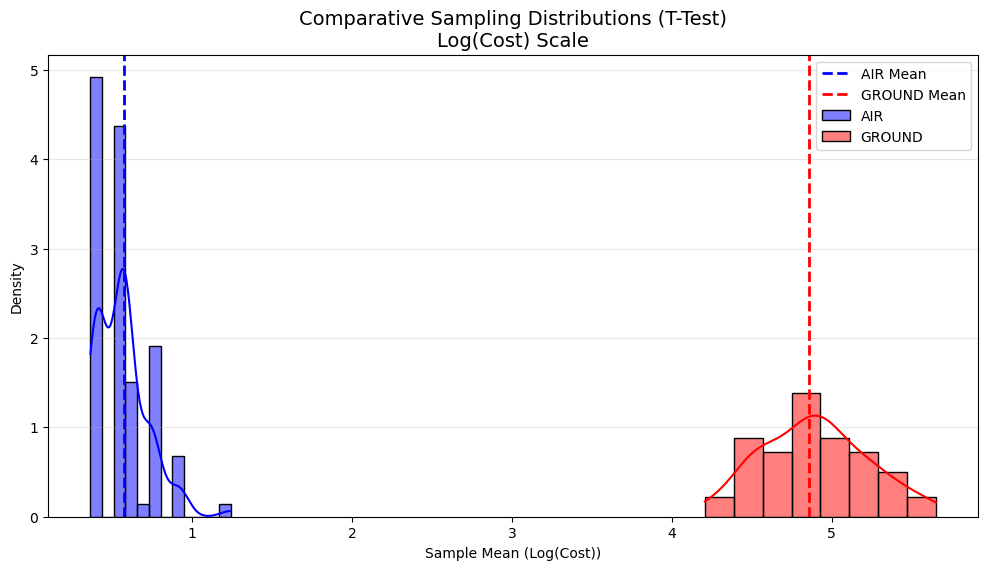


✅ Significant difference detected (p < 0.05)

📌 Insight: The separation of the two curves confirms the statistical difference.


In [23]:
auto_stat_test_cost_sampling(shipment_df,sample_size=30,n_iterations=100,sampling_method='stratified')

Sample Sizes → AIR: 20, GROUND: 20

Selected Test : T-Test
Test Statistic: -5.326
P-value       : 0.0


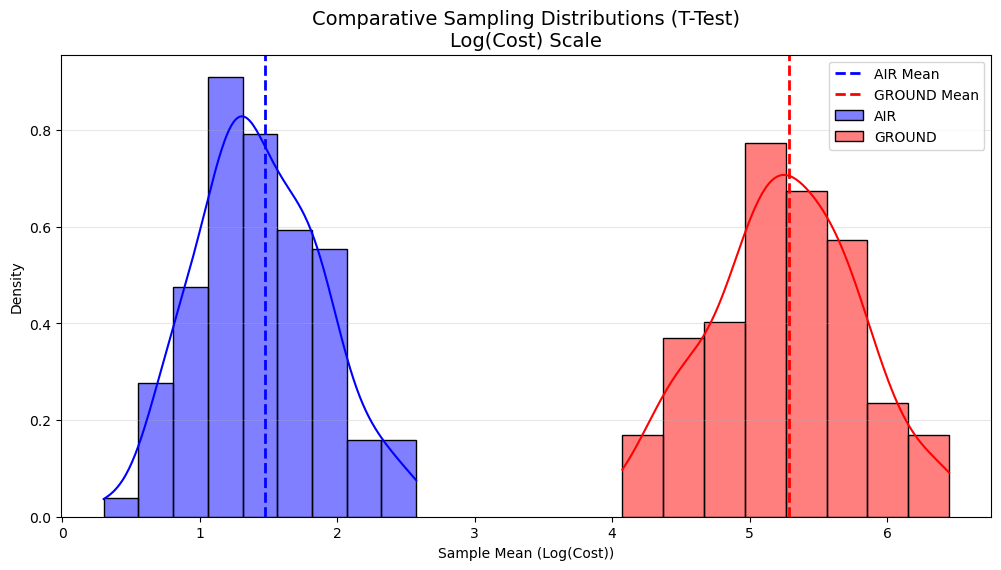


✅ Significant difference detected (p < 0.05)

📌 Insight: The separation of the two curves confirms the statistical difference.


In [24]:
auto_stat_test_cost_sampling(shipment_df,sample_size=20,n_iterations=100,sampling_method='simple_random')

### Hypothesis Test (Chi Square Test)

In [25]:
from statistical.chi_square import carrier_delivery_chi_square_test
carrier_delivery_chi_square_test(shipment_df)

Contingency Table:\n


on_time_flag,0,1
carrier_name,,
V444_0,25913,25881
V444_1,0,83880



Chi-Square Statistic : 51870.225
P-value              : 0.0
Degrees of Freedom   : 1

✅ Carrier significantly impacts delivery performance

Carrier Performance (%):



on_time_flag,0,1
carrier_name,,
V444_0,50.030892,49.969108
V444_1,0.000000,100.000000


"📌 Business Insight:
    Carriers with higher delayed shipment percentages
    should be reviewed for route optimization,
    SLA violations, or operational inefficiencies.
    


## Implementing ML Model 

### Feature Selection for implementing Supervised ML Model

In [26]:
from visualization.plots import perform_feature_selection_eda

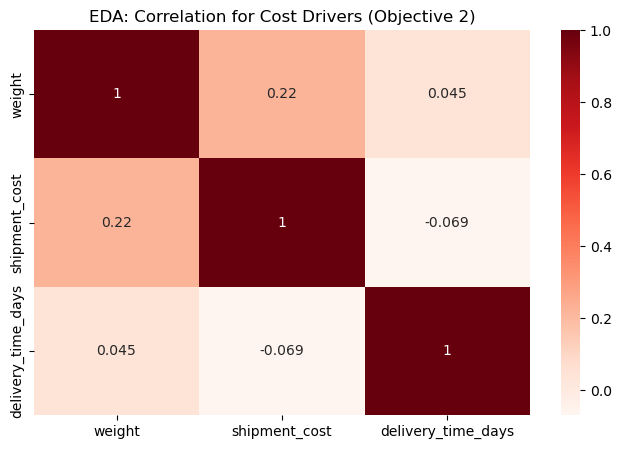

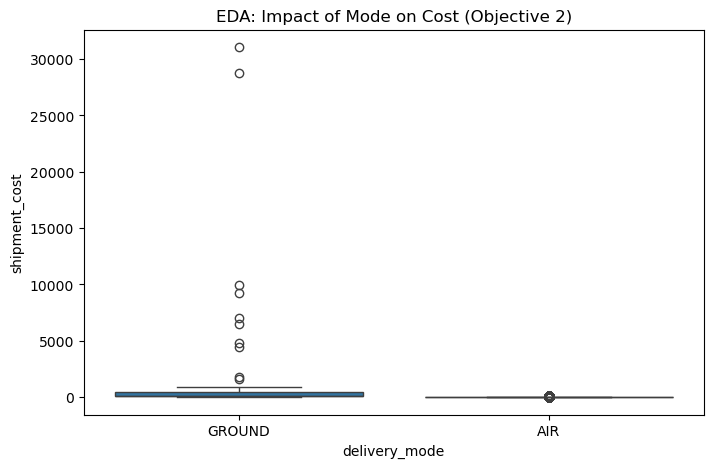

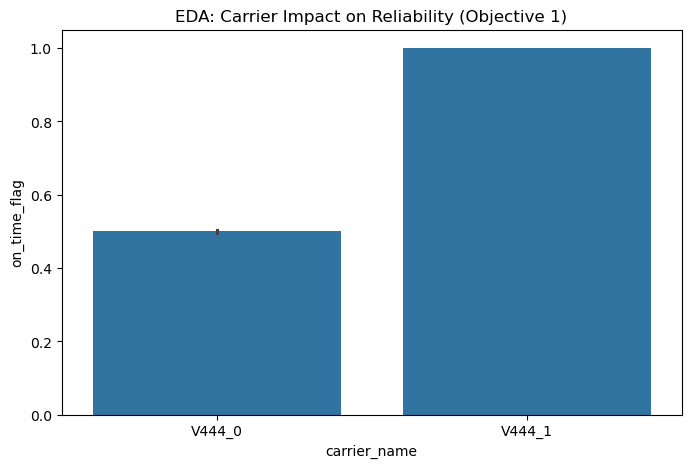

In [27]:
df=shipment_df.copy()
perform_feature_selection_eda(df)

## Implementing Regression Models 

In [28]:
### Importing libaries for implementing and evaluating regression Models
from models.linear_regression import run_linear_regression
from models.random_forest_regression import run_random_forest
from models.evaluate_model import evaluate_regression
from visualization.plots import plot_model_results

### Linear Regression Model 

In [29]:
model,X_test,y_test=run_linear_regression(df)

In [30]:
### evaluating linear model and plotting the model result
y_lin_pred=evaluate_regression(model,X_test,y_test)

R2 Score: -0.062
MAE: 19.89


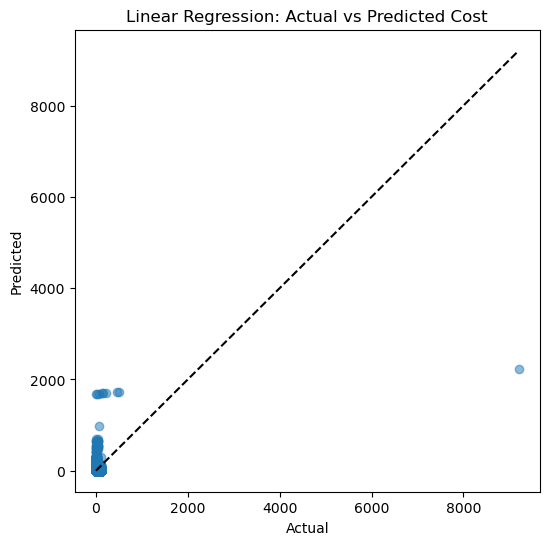

In [31]:
#plotting the results for Linear Regression Model  
plot_model_results(y_test,y_lin_pred,'Linear Regression')

### Random Forest Regression Model

In [32]:
model_rf,X_test_rf,y_test_rf=run_random_forest(df)

In [33]:
### evaluating random forest regression  model and plotting the model result
y_rf_pred=evaluate_regression(model_rf,X_test_rf,y_test_rf)

R2 Score: 0.766
MAE: 15.72


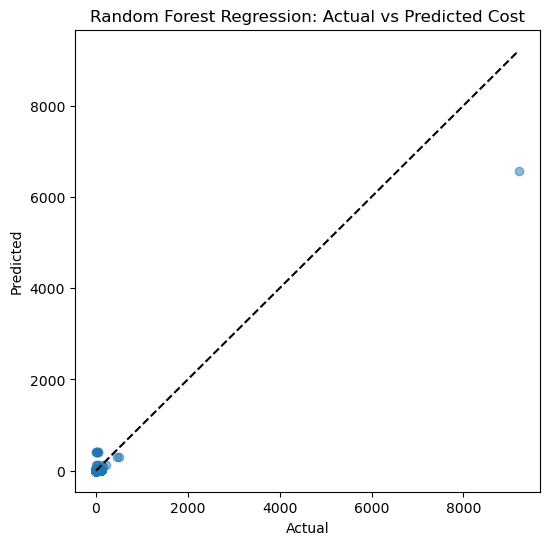

In [34]:
### plotting the results for random forest regression Model
plot_model_results(y_test_rf,y_rf_pred,'Random Forest Regression')

### Implementing the random forest tree 

In [35]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

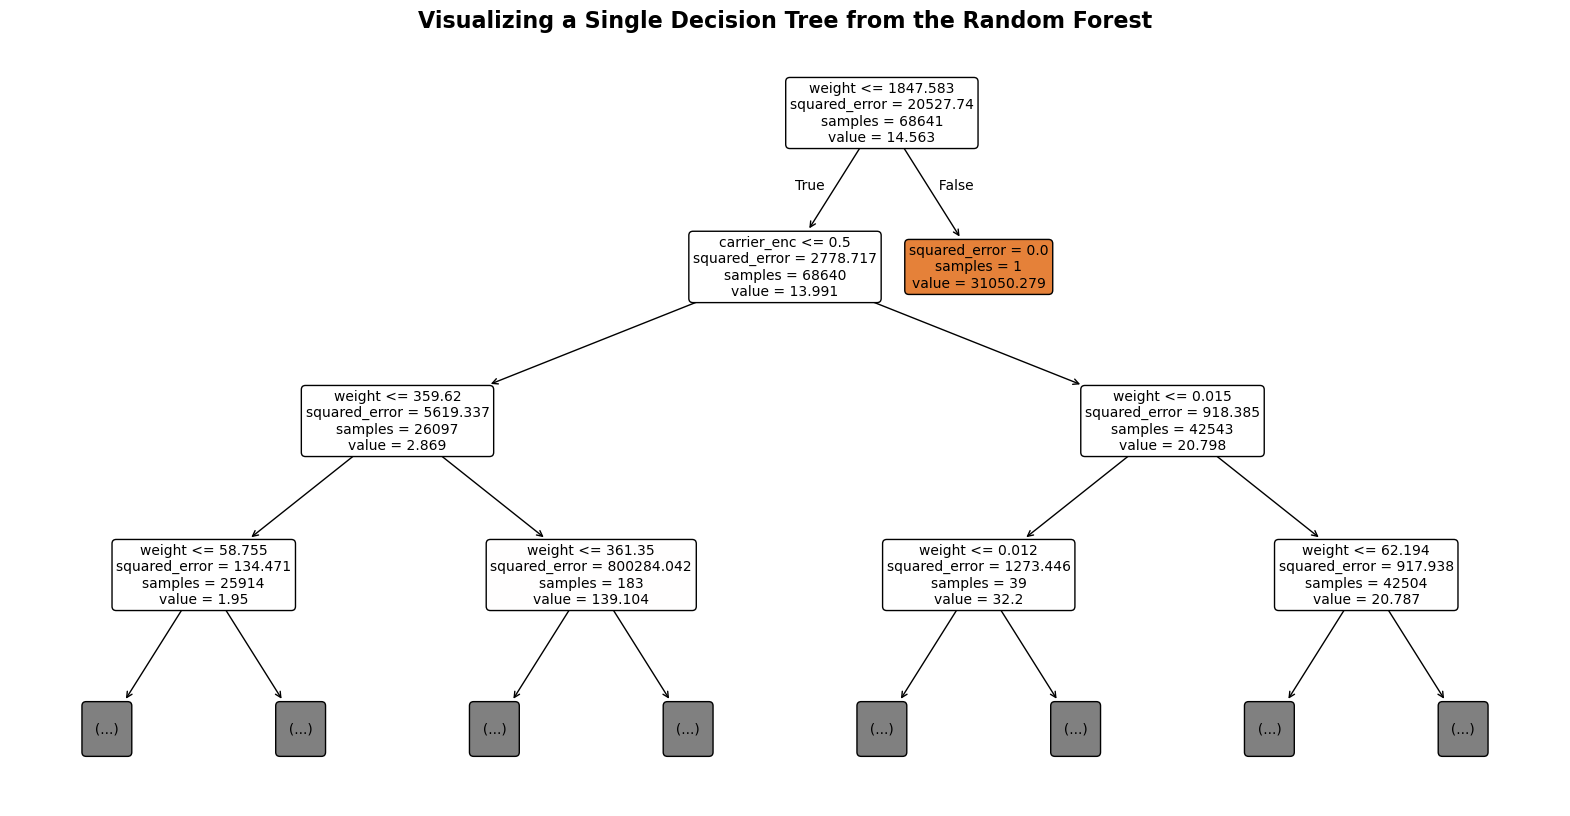

In [36]:
#Extract the first tree estimator
single_tree = model_rf.estimators_[0]

#Plot the tree structure
plt.figure(figsize=(20, 10))  # Set a large figure size so text is readable
plot_tree(
    single_tree,
    feature_names=['weight', 'carrier_enc'],  # The features you trained X on
    max_depth=3,                              # Limits depth so the plot isn't chaotic
    filled=True,                              # Colors the nodes by their predicted values
    rounded=True,                             # Makes the node boxes rounded
    fontsize=10
)
plt.title("Visualizing a Single Decision Tree from the Random Forest", fontsize=16, fontweight='bold')
# plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

## Implementing Classification  Models 

In [37]:
### Importing libaries for implementing and evaluating classification Models
from models.logistic_regression import run_logistic_regression
from models.Knn_Classifier import run_knn
from models.evaluate_model import evaluate_classification
from visualization.plots import plot_classification_results

### Logistic Regression Model 

In [38]:
model_log,X_test_log,y_test_log=run_logistic_regression(df)

In [39]:
### evaluating logistics regression classification  model and plotting the model result
cm=evaluate_classification(model_log,X_test_log,y_test_log)

Accuracy Score: 0.808
F1_Score: 0.894


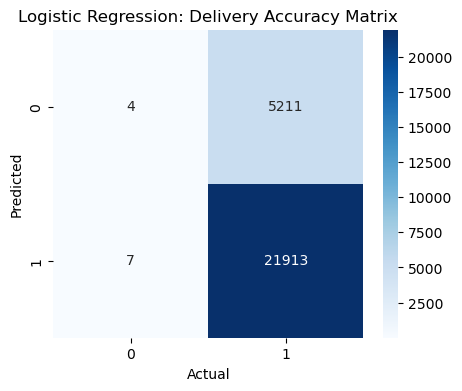

In [40]:
### plotting the results for logistics  regression Model
plot_classification_results(cm,'Logistic Regression')

### K Nearest Classifier Model 

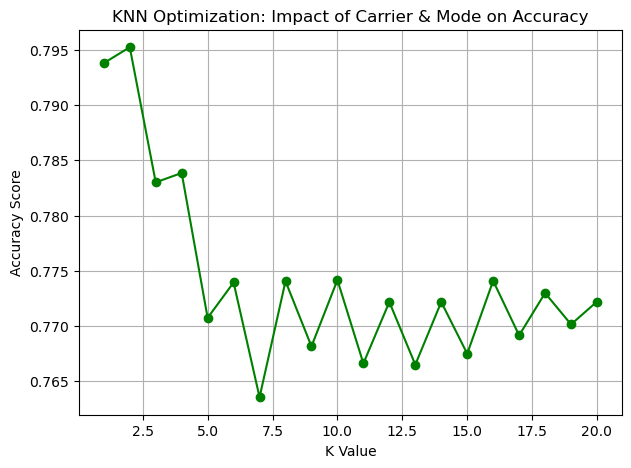

Optimal K for Carrier/Mode analysis: 2


2

In [41]:
# Find the optimal value of K 
from models.Knn_Classifier import find_optimal_k,run_knn
find_optimal_k(df)

In [42]:
# therefore we choose the k value as 2
model_knn,X_test_knn,y_test_knn=run_knn(df,2)

In [43]:
### evaluating knnclassifier  model and plotting the model result
cm=evaluate_classification(model_knn,X_test_knn,y_test_knn)

Accuracy Score: 0.795
F1_Score: 0.865


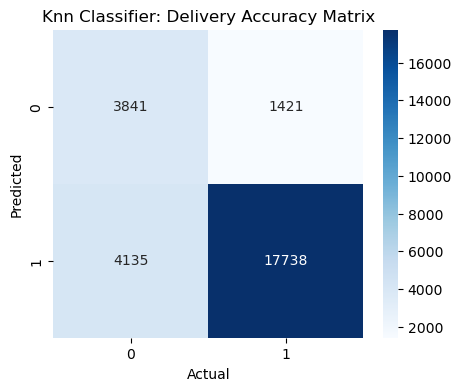

In [44]:
### plotting the results for Knn classifier Model
plot_classification_results(cm,'Knn Classifier')

## Implementing Unsupervised Algorithm

# K Mean's Algorithm 

In [45]:
### Importing libaries for implementing and evaluating Kmeans Models
from preprocessing.Clean_data import cap_outliers_iqr
from visualization.plots import perform_feature_selection_eda_Kmeans
from visualization.plots import plot_Kmeans_cluster_scaled,plot_Kmeans_cluster_original
from models.Kmeans import run_KMeans,find_optimal_K_elbowmethod,find_optimal_K_silhouette
from models.evaluate_model import evaluateKmeans

In [46]:
numerical_ware_df=warehouse_df.select_dtypes(include='number')

In [47]:
numerical_ware_df.head()

,warehouse_capacity_units,current_inventory_units,inventory_turnover_ratio,order_fulfilment_rate,avg_pick_pack_time_min,warehouse_utilization_pct,labour_hours_per_day,operational_cost_per_day,inventory_utilization,cost_per_unit,labor_productivity,log_operational_cost
0,246,149,2.82,100.0,22,60.57,3,42.17,0.605691,0.282830,48.064516,3.765146
1,179,112,2.82,100.0,24,62.57,3,9.61,0.625698,0.085727,36.129032,2.361797
2,2488,2041,2.82,100.0,24,82.03,4,831.20,0.820338,0.407231,497.804878,6.724073
3,8631,6252,2.82,100.0,23,72.44,12,610.38,0.724366,0.097628,516.694215,6.415719
4,3094,1780,2.82,100.0,25,57.53,3,169.99,0.575307,0.095495,574.193548,5.141605


In [48]:
# removing outliers in each numerical column
cleaned_ware_num_df=cap_outliers_iqr(numerical_ware_df)

In [49]:
cleaned_ware_num_df.head()

,warehouse_capacity_units,current_inventory_units,inventory_turnover_ratio,order_fulfilment_rate,avg_pick_pack_time_min,warehouse_utilization_pct,labour_hours_per_day,operational_cost_per_day,inventory_utilization,cost_per_unit,labor_productivity,log_operational_cost
0,246.0,149,2.82,100.0,22,60.57,3.0,42.17,0.605691,0.176327,48.064516,3.765146
1,179.0,112,2.82,100.0,24,62.57,3.0,9.61,0.625698,0.085727,36.129032,2.361797
2,2488.0,2041,2.82,100.0,24,82.03,4.0,831.20,0.820338,0.176327,497.804878,6.724073
3,8631.0,6252,2.82,100.0,23,72.44,12.0,610.38,0.724366,0.097628,516.694215,6.415719
4,3094.0,1780,2.82,100.0,25,57.53,3.0,169.99,0.575307,0.095495,574.193548,5.141605


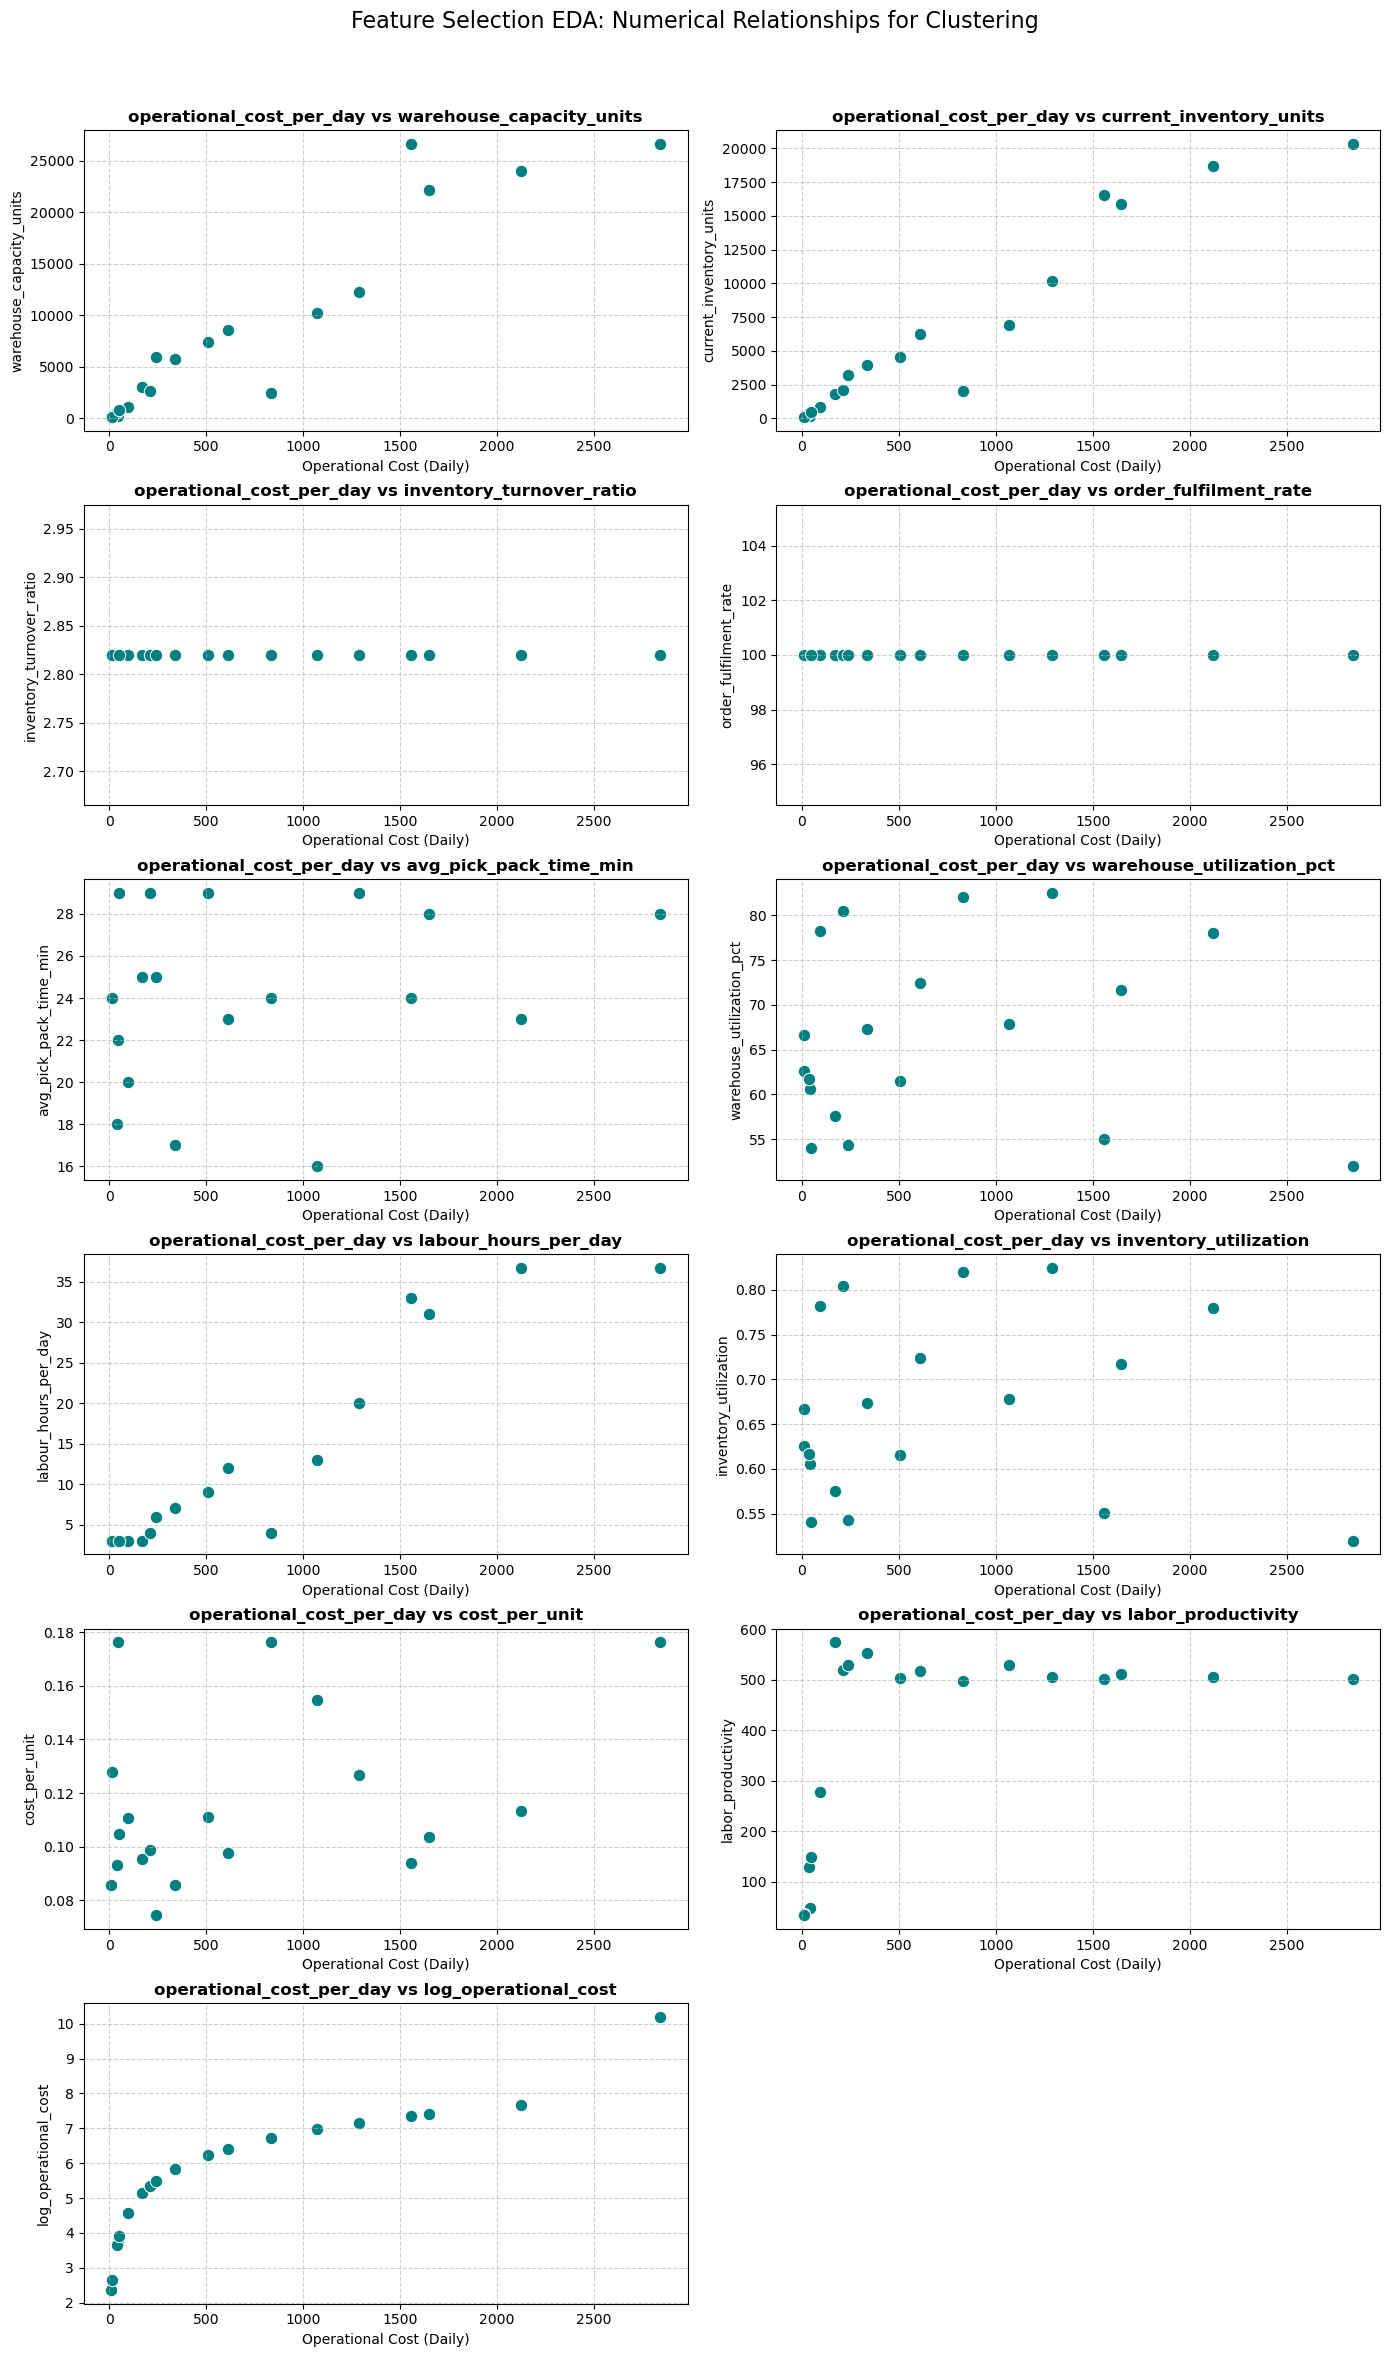

In [50]:
perform_feature_selection_eda_Kmeans(cleaned_ware_num_df)

#### Randomly initalizing the n.o of clusters to test the model performance 

In [51]:
features_selected=["operational_cost_per_day","warehouse_capacity_units","labor_productivity"]
Kmeans_5,X_scaled=run_KMeans(cleaned_ware_num_df,features_selected,5)

In [52]:
# evaluating the performance with k=5
labels_5=Kmeans_5.labels_
evaluateKmeans(X_scaled,labels_5)

--- KMeans Evaluation Metrics ---
Silhouette Score (Higher is better): 0.559
Davies-Bouldin Index (Lower is better): 0.382
Calinski-Harabasz Score: 68.638


{'silhouette': 0.5585512002861384,
 'db_index': 0.38209064380469954,
 'ch_score': 68.63824637998874}

In [53]:
ware_num_df=cleaned_ware_num_df.copy()
ware_num_df['cluster_num_5']=labels_5

In [54]:
ware_num_df['cluster_num_5'].value_counts()

cluster_num_5
0    7
2    6
4    3
3    2
1    1
Name: count, dtype: int64

In [55]:
X=ware_num_df[["operational_cost_per_day", "warehouse_capacity_units","labor_productivity"]]
labels=ware_num_df['cluster_num_5']
features_names=X.copy()
centers=Kmeans_5.cluster_centers_

#### Plotting cluster graph For K=5

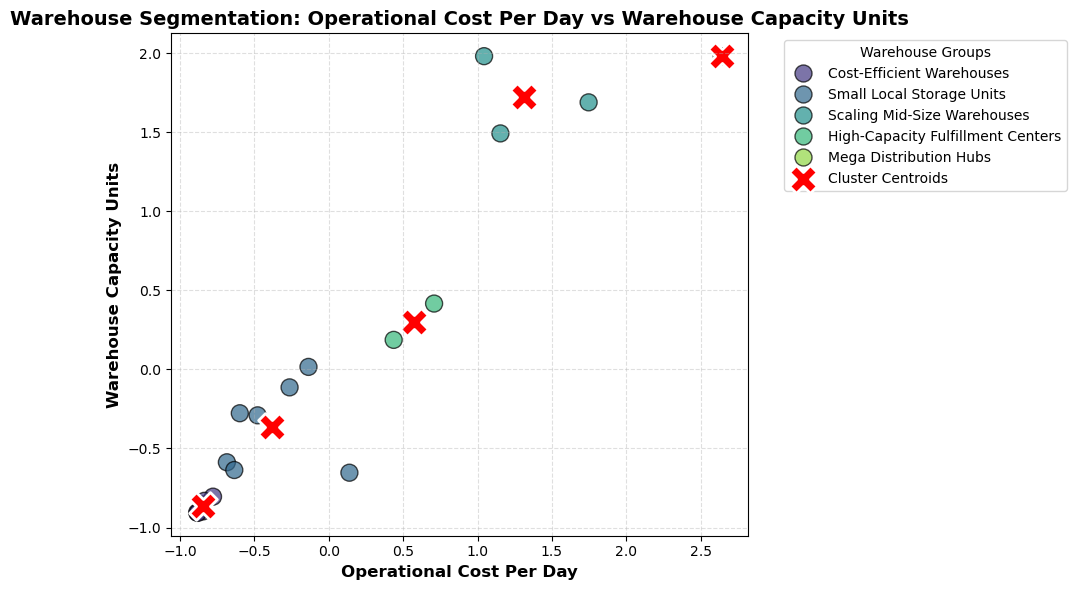

In [56]:
# scaled Feature 
features_names=['operational_cost_per_day','warehouse_capacity_units','labor_productivity']
plot_Kmeans_cluster_scaled(X_scaled, labels,centers,features_names,y_feature_index=1)

#### Finding the optimal value of K for representing the number of clusters 

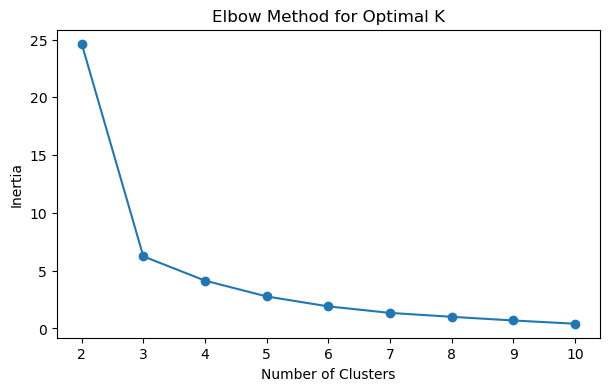

In [57]:
find_optimal_K_elbowmethod(X_scaled)

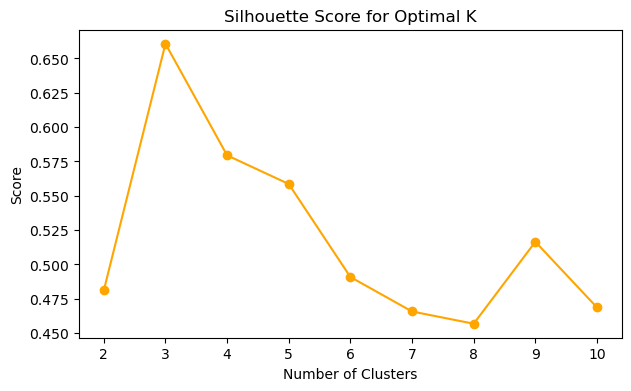

3

In [58]:
find_optimal_K_silhouette(X_scaled)

<pre><b>Observation:</b>Here both graph are showing different optimal k value in which 2 is showing as the optimal value in silhoutte score graph and 3 is showing the optimal k value in elobw method  but we need a safe side to select the k value so we go for the option 3 as the valid/optimal K value  
<pre>  

#### Plotting cluster graph on  Opeartional Cost vs Labour Productivity 

#### implementing the K means model for K=3

In [59]:
# plotiing cluster's for k=3 
kmeans_3,Xscaled=run_KMeans(cleaned_ware_num_df,features_selected,3)
labels_3=kmeans_3.labels_
evaluateKmeans(X_scaled,labels_3)

--- KMeans Evaluation Metrics ---
Silhouette Score (Higher is better): 0.661
Davies-Bouldin Index (Lower is better): 0.412
Calinski-Harabasz Score: 65.113


{'silhouette': 0.6607205349567806,
 'db_index': 0.4117018820510832,
 'ch_score': 65.11306538181803}

In [60]:
ware_num_df['cluster_num_3']=labels_3
ware_num_df['cluster_num_3'].value_counts()

cluster_num_3
0    9
2    6
1    4
Name: count, dtype: int64

In [61]:
X=ware_num_df[["operational_cost_per_day", "warehouse_capacity_units","labor_productivity"]]
labels=ware_num_df['cluster_num_3']
features_names=X.copy()

#### Plotting cluster graph For K=3

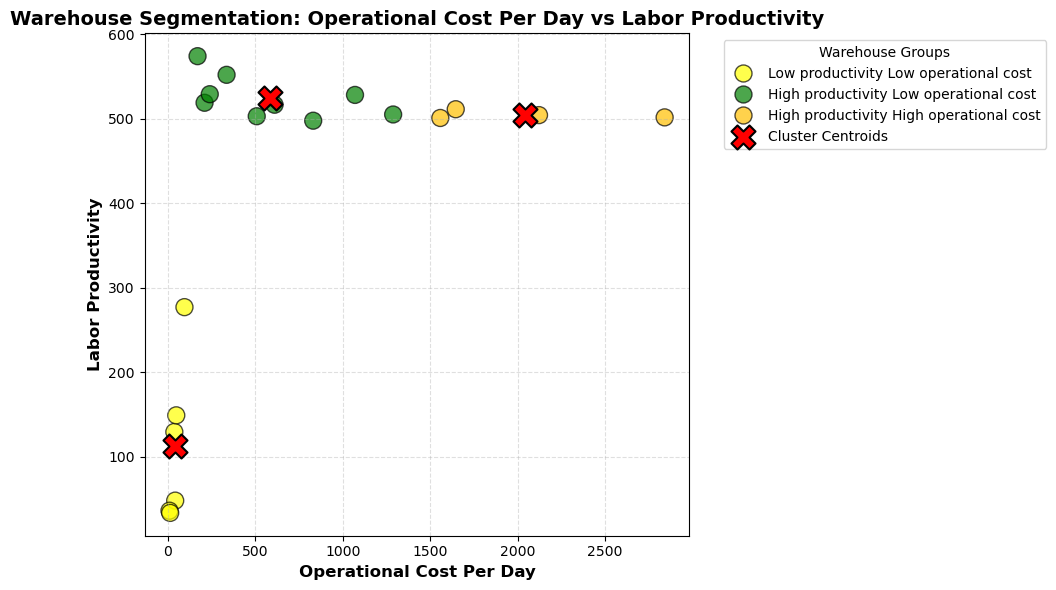

In [62]:
# without scaled feature 
plot_Kmeans_cluster_original(X,labels,features_names, y_feature_index=2)

In [ ]:
# with scaled features 
# features_names=['operational_cost_per_day','labour_hours_per_day','warehouse_capacity_units']
# plot_Kmeans_cluster_scaled(X_scaled, labels,centers,features_names,y_feature_index=2)

In [4]:
from preprocessing.feature_engineering import feature_engineering_pipeline
from llm.business_qa import q1_carriers_routes_highest_delay_2
   
shipment_df, warehouse_df, inventory_df = feature_engineering_pipeline(
    shipment_df, warehouse_df, inventory_df
)

answer1, table1 = q1_carriers_routes_highest_delay_2(warehouse_df)
print("Q1 Answer:\n", answer1)
print(table1)

Q1 Answer:
 **Lead Time Analysis:**
* Top drivers: High warehouse utilization in Plant 1 (78.01%) and Plant 3 (71.68%)
* Risk areas: Potential delays and increased operational cost
* Business action: Optimize warehouse capacity in Plant 1 and Plant 3 to reduce lead time and operational cost.
  warehouse_id  warehouse_utilization_pct  log_operational_cost
2      PLANT16                      51.97             10.196099
0      PLANT01                      78.01              7.660623
1      PLANT03                      71.68              7.406753
3      PLANT13                      55.02              7.351749
4      PLANT14                      82.50              7.161777
